In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv


In [2]:
# Reading data
holidays = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv")
oil = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv")
sample = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv")
stores = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv")
test = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv")
train = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv")
transactions = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv")

# Info of datasets

In [3]:
holidays.info()
holidays.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [4]:
oil.info()
oil.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [5]:
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28512 non-null  int64 
 1   date         28512 non-null  object
 2   store_nbr    28512 non-null  int64 
 3   family       28512 non-null  object
 4   onpromotion  28512 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [7]:
transactions.info()
transactions.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [8]:
sample.info()
sample.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28512 non-null  int64  
 1   sales   28512 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 445.6 KB


,id,sales
0,3000888,0.0
1,3000889,0.0
2,3000890,0.0
3,3000891,0.0
4,3000892,0.0


# # Imports & style

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [10]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error

DATA_DIR = "/kaggle/input"          # <-- change if your CSVs live elsewhere
OUT_PATH = "submission.csv"
N_VALID_DAYS = 16        # test.csv covers 16 days -> mimic that as validation horizon
SEED = 42

np.random.seed(SEED)

def p(name):
    return os.path.join(DATA_DIR, name)

# Loading datsets

In [11]:
print("Loading data...")
train = pd.read_csv(p("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv"), parse_dates=["date"])
test = pd.read_csv(p("/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv"), parse_dates=["date"])
holidays = pd.read_csv(p("/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv"), parse_dates=["date"])
oil = pd.read_csv(p("/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv"), parse_dates=["date"])
transactions = pd.read_csv(p("/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv"), parse_dates=["date"])
sample_sub = pd.read_csv(p("/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv"))

stores_path = p("/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv")
stores = pd.read_csv(stores_path) if os.path.exists(stores_path) else None
if stores is None:
    print("stores.csv not found - store metadata features (city/state/type/cluster) will be skipped.")

print(f"train: {train.shape}, test: {test.shape}")

Loading data...
train: (3000888, 6), test: (28512, 5)


In [12]:
# Oil price — fill gaps (weekends/holidays have no price) via interpolation
oil = oil.set_index("date").asfreq("D")
oil["dcoilwtico"] = oil["dcoilwtico"].interpolate(method="linear")
oil["dcoilwtico"] = oil["dcoilwtico"].bfill().ffill()
oil = oil.reset_index().rename(columns={"dcoilwtico": "oil_price"})
oil.head()

,date,oil_price
0,2013-01-01,93.140000
1,2013-01-02,93.140000
2,2013-01-03,92.970000
3,2013-01-04,93.120000
4,2013-01-05,93.146667


In [13]:
# Holidays — build clean daily national/regional/local holiday flags
# Drops "transferred" holidays from the date they were originally observed on, and
# treats "Transfer", "Additional", and "Bridge" rows as the holiday actually occurring then.

hol = holidays.copy()
hol = hol[~((hol["type"] == "Holiday") & (hol["transferred"] == True))]

hol["is_work_day"] = (hol["type"] == "Work Day").astype(int)
hol["is_event"] = (hol["type"] == "Event").astype(int)
hol["is_national_holiday"] = (
    (hol["locale"] == "National") &
    (hol["type"].isin(["Holiday", "Transfer", "Additional", "Bridge"]))
).astype(int)

hol["is_regional_holiday"] = (
    (hol["locale"] == "Regional") &
    (hol["type"].isin(["Holiday", "Transfer", "Additional", "Bridge"]))
).astype(int)

hol["is_local_holiday"] = (
    (hol["locale"] == "Local") &
    (hol["type"].isin(["Holiday", "Transfer", "Additional", "Bridge"]))
).astype(int)

national_hol = (
    hol[hol["is_national_holiday"] == 1]
    .groupby("date")["is_national_holiday"]
    .max()
    .reset_index()
)

events = (
    hol[hol["is_event"] == 1]
    .groupby("date")["is_event"]
    .max()
    .reset_index()
)

work_days = (
    hol[hol["is_work_day"] == 1]
    .groupby("date")["is_work_day"]
    .max()
    .reset_index()
)

# Regional/local holidays depend on the store's state/city, so keep them
# separately keyed for a later merge (only usable if stores.csv is present).
regional_hol = (
    hol[hol["is_regional_holiday"] == 1][["date", "locale_name"]]
    .rename(columns={"locale_name": "state"})
)
regional_hol["is_regional_holiday"] = 1
regional_hol = regional_hol.drop_duplicates(["date", "state"])

local_hol = (
    hol[hol["is_local_holiday"] == 1][["date", "locale_name"]]
    .rename(columns={"locale_name": "city"})
)
local_hol["is_local_holiday"] = 1
local_hol = local_hol.drop_duplicates(["date", "city"])

In [14]:
# Transactions — sort by store/date (used as a lag/rolling signal later, not a raw feature)
transactions = transactions.sort_values(["store_nbr", "date"])

In [15]:
# Combine train + test so feature engineering (lags, calendar, etc.) is consistent across the full timeline
train["is_test"] = 0
test["is_test"] = 1
test["sales"] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True, sort=False)
full = full.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)
full.shape

(3029400, 7)

In [16]:
# Merge external features (oil, holidays, store metadata, transactions)
full = full.merge(oil[["date", "oil_price"]], on="date", how="left")
full = full.merge(national_hol, on="date", how="left")
full = full.merge(events, on="date", how="left")
full = full.merge(work_days, on="date", how="left")
for col in ["is_national_holiday", "is_event", "is_work_day"]:
    full[col] = full[col].fillna(0).astype(int)

if stores is not None:
    full = full.merge(stores, on="store_nbr", how="left")
    full = full.merge(regional_hol, on=["date", "state"], how="left")
    full = full.merge(local_hol, on=["date", "city"], how="left")
    full["is_regional_holiday"] = full["is_regional_holiday"].fillna(0).astype(int)
    full["is_local_holiday"] = full["is_local_holiday"].fillna(0).astype(int)
else:
    full["is_regional_holiday"] = 0
    full["is_local_holiday"] = 0

full = full.merge(transactions, on=["date", "store_nbr"], how="left")
full.head()

,id,date,store_nbr,family,sales,onpromotion,is_test,oil_price,is_national_holiday,is_event,is_work_day,city,state,type,cluster,is_regional_holiday,is_local_holiday,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0,93.140000,1,0,0,Quito,Pichincha,D,13,0,0,NaN
1,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,0,93.140000,0,0,0,Quito,Pichincha,D,13,0,0,2111.0
2,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,0,92.970000,0,0,0,Quito,Pichincha,D,13,0,0,1833.0
3,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,0,93.120000,0,0,0,Quito,Pichincha,D,13,0,0,1863.0
4,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,0,93.146667,0,0,1,Quito,Pichincha,D,13,0,0,1509.0


In [17]:
# Calendar features
full["year"] = full["date"].dt.year
full["month"] = full["date"].dt.month
full["day"] = full["date"].dt.day
full["dayofweek"] = full["date"].dt.dayofweek
full["weekofyear"] = full["date"].dt.isocalendar().week.astype(int)
full["is_weekend"] = (full["dayofweek"] >= 5).astype(int)
full["is_month_start"] = full["date"].dt.is_month_start.astype(int)
full["is_month_end"] = full["date"].dt.is_month_end.astype(int)
# Ecuador public-sector wages are paid on the 15th and the last day of month,
# which is well known to spike sales in this dataset.
full["is_payday"] = ((full["day"] == 15) | full["date"].dt.is_month_end).astype(int)
# Earthquake of 2016-04-16 measurably disrupted sales for weeks after.
full["days_since_quake"] = (full["date"] - pd.Timestamp("2016-04-16")).dt.days.clip(lower=0)

In [18]:
# Categorical encoding
cat_cols = ["family"]
if stores is not None:
    cat_cols += ["city", "state", "type", "cluster"]

for c in cat_cols:
    full[c] = full[c].astype("category")

In [19]:
# Lag / rolling features per (store_nbr, family)
#
# Built on log1p(sales) to stabilize variance. NaNs (test horizon + start of
# history) are left for LightGBM to handle natively.

full["log_sales"] = np.log1p(full["sales"])

# Group by store and product family
grp = full.groupby(["store_nbr", "family"], observed=True)["log_sales"]

# Lag features
for lag in [1, 7, 14, 21, 28]:
    full[f"lag_{lag}"] = grp.shift(lag)

# Rolling statistics (computed within each store-family group)
for window in [7, 14, 30]:
    full[f"roll_mean_{window}"] = grp.transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    )
    full[f"roll_std_{window}"] = grp.transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).std()
    )

# onpromotion is known for both train and test (future promotions are provided)
full["onpromotion"] = full["onpromotion"].fillna(0)

# Transactions are unknown at test time -> use lag/rolling features instead
trans_grp = full.groupby("store_nbr", observed=True)["transactions"]

full["transactions_lag7"] = trans_grp.shift(7)

full["transactions_roll_mean_7"] = trans_grp.transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)

# Drop the original transactions column to prevent leakage
full = full.drop(columns=["transactions"])

In [20]:
# Split back into train / validation / test
feature_cols = [c for c in full.columns if c not in
                ["id", "date", "sales", "log_sales", "is_test"]]

train_full = full[full["is_test"] == 0].copy()
test_full = full[full["is_test"] == 1].copy()

# Drop the earliest rows where lag/rolling features are still all-NaN
# (first ~28 days of the whole series) -- keeps early-history noise out.
train_full = train_full[train_full["date"] >= train_full["date"].min() + pd.Timedelta(days=28)]

max_date = train_full["date"].max()
valid_start = max_date - pd.Timedelta(days=N_VALID_DAYS - 1)

X_train = train_full[train_full["date"] < valid_start][feature_cols]
y_train = train_full[train_full["date"] < valid_start]["log_sales"]

X_valid = train_full[train_full["date"] >= valid_start][feature_cols]
y_valid = train_full[train_full["date"] >= valid_start]["log_sales"]

X_test = test_full[feature_cols]

print(f"Train rows: {len(X_train):,} | Valid rows: {len(X_valid):,} | Test rows: {len(X_test):,}")

Train rows: 2,922,480 | Valid rows: 28,512 | Test rows: 28,512


In [21]:
# Train LightGBM
cat_feature_names = [c for c in cat_cols if c in feature_cols]

lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_feature_names, free_raw_data=False)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=cat_feature_names,
                         reference=lgb_train, free_raw_data=False)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 255,
    "max_depth": -1,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "verbosity": -1,
    "seed": SEED,
}

print("Training LightGBM...")
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=5000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100),
    ],
)

Training LightGBM...
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.407552	valid's rmse: 0.406305
[200]	train's rmse: 0.365201	valid's rmse: 0.381403
[300]	train's rmse: 0.355864	valid's rmse: 0.377984
[400]	train's rmse: 0.350911	valid's rmse: 0.376535
[500]	train's rmse: 0.347483	valid's rmse: 0.375907
[600]	train's rmse: 0.344528	valid's rmse: 0.375036
[700]	train's rmse: 0.341907	valid's rmse: 0.374381
[800]	train's rmse: 0.339616	valid's rmse: 0.373929
[900]	train's rmse: 0.337443	valid's rmse: 0.373536
[1000]	train's rmse: 0.33544	valid's rmse: 0.373282
[1100]	train's rmse: 0.333538	valid's rmse: 0.373086
[1200]	train's rmse: 0.33176	valid's rmse: 0.373069
[1300]	train's rmse: 0.330037	valid's rmse: 0.373122
Early stopping, best iteration is:
[1230]	train's rmse: 0.331249	valid's rmse: 0.372979


In [22]:
# Validate — report RMSLE (the competition's actual metric)
valid_pred_log = model.predict(X_valid, num_iteration=model.best_iteration)
valid_pred = np.clip(np.expm1(valid_pred_log), 0, None)
valid_true = np.expm1(y_valid)
rmsle = np.sqrt(mean_squared_log_error(valid_true, valid_pred))
print(f"Validation RMSLE: {rmsle:.5f}")

Validation RMSLE: 0.37296


In [23]:
# Retrain on full history at the best iteration, then predict the real test set
X_full = train_full[feature_cols]
y_full = train_full["log_sales"]
lgb_full = lgb.Dataset(X_full, label=y_full, categorical_feature=cat_feature_names)

final_model = lgb.train(
    params,
    lgb_full,
    num_boost_round=model.best_iteration or 1000,
)

test_pred_log = final_model.predict(X_test)
test_pred = np.clip(np.expm1(test_pred_log), 0, None)

In [24]:
# Build submission.csv
submission = test_full[["id"]].copy()
submission["sales"] = test_pred
submission = sample_sub[["id"]].merge(submission, on="id", how="left")  # preserve exact row order
submission["sales"] = submission["sales"].fillna(0)

submission.to_csv(OUT_PATH, index=False)
print(f"Saved -> {OUT_PATH}")
submission.head()

Saved -> submission.csv


,id,sales
0,3000888,4.704143
1,3000889,0.006001
2,3000890,5.985409
3,3000891,2281.315553
4,3000892,0.013646


In [25]:
# Feature importance (quick sanity check)
imp = pd.DataFrame({
    "feature": final_model.feature_name(),
    "importance": final_model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False)

print("Top 15 features by gain:")
imp.head(15)

Top 15 features by gain:


,feature,importance
28,roll_mean_7,2.166963e+08
23,lag_1,2.198120e+07
30,roll_mean_14,1.786922e+07
24,lag_7,1.677712e+07
32,roll_mean_30,3.477758e+06
25,lag_14,1.831180e+06
1,family,8.175232e+05
14,month,8.025492e+05
15,day,7.195895e+05
26,lag_21,7.085791e+05


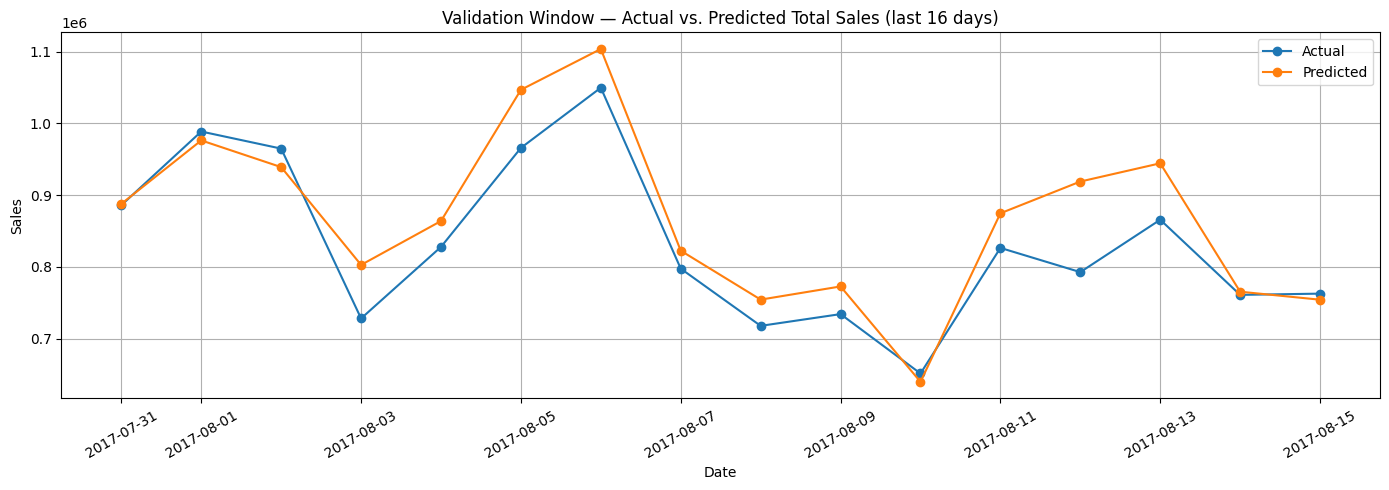

In [26]:
# Validation window — actual vs. predicted (training)
valid_dates = train_full[train_full["date"] >= valid_start]["date"].values

valid_plot_df = pd.DataFrame({
    "date": valid_dates,
    "actual": valid_true.values,
    "predicted": valid_pred,
}).groupby("date").sum().reset_index()

fig, ax = plt.subplots()
ax.plot(valid_plot_df["date"], valid_plot_df["actual"], label="Actual", marker="o")
ax.plot(valid_plot_df["date"], valid_plot_df["predicted"], label="Predicted", marker="o")
ax.set_title(f"Validation Window — Actual vs. Predicted Total Sales (last {N_VALID_DAYS} days)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

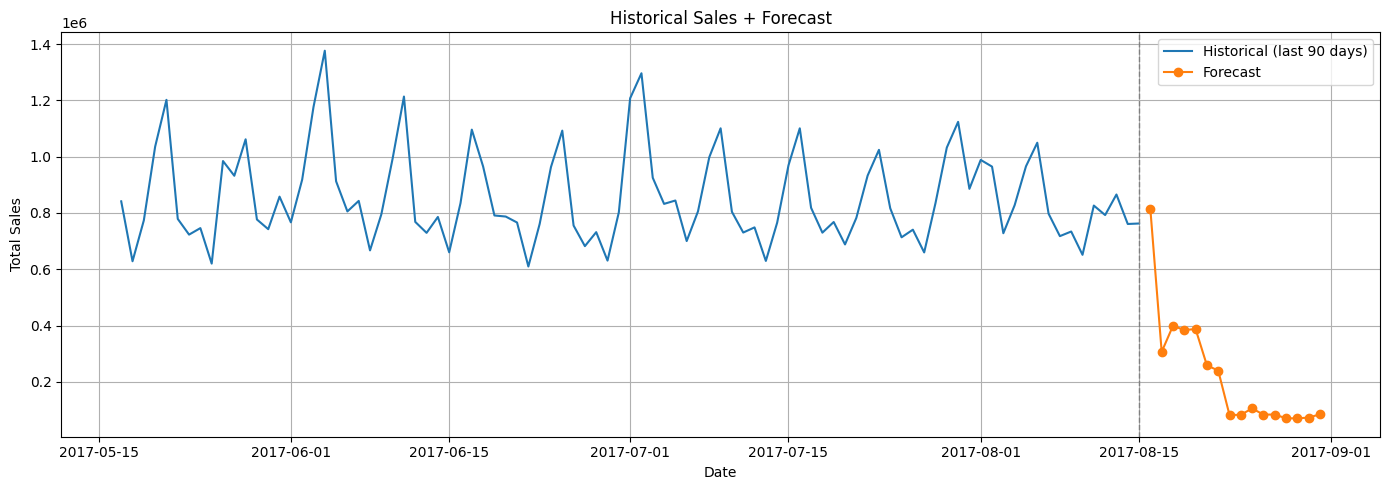

In [27]:
# Historical + forecast stitched together (prediction)
hist_daily = train.groupby("date")["sales"].sum().reset_index()
hist_daily = hist_daily[hist_daily["date"] >= hist_daily["date"].max() - pd.Timedelta(days=90)]

forecast_daily = test_full[["date"]].copy()
forecast_daily["sales"] = test_pred
forecast_daily = forecast_daily.groupby("date")["sales"].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(hist_daily["date"], hist_daily["sales"], label="Historical (last 90 days)", color="tab:blue")
ax.plot(forecast_daily["date"], forecast_daily["sales"], label="Forecast", color="tab:orange", marker="o")
ax.axvline(hist_daily["date"].max(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Historical Sales + Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales")
ax.legend()
plt.tight_layout()
plt.show()

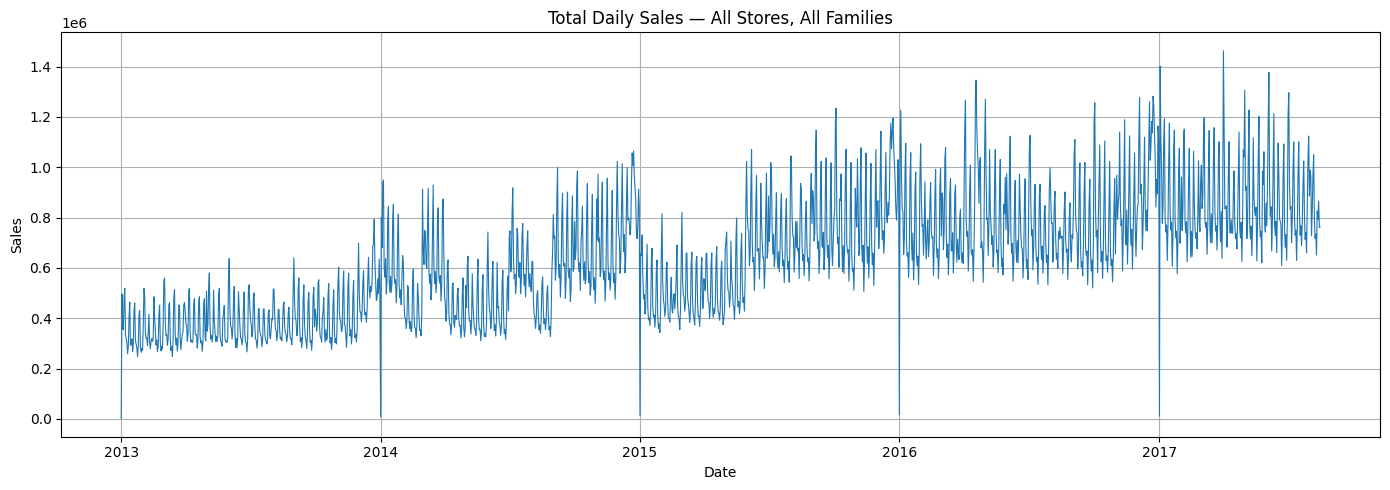

In [28]:
# Overall daily total sales
daily_total = train.groupby("date")["sales"].sum()

fig, ax = plt.subplots()
ax.plot(daily_total.index, daily_total.values, linewidth=0.8)
ax.set_title("Total Daily Sales — All Stores, All Families")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

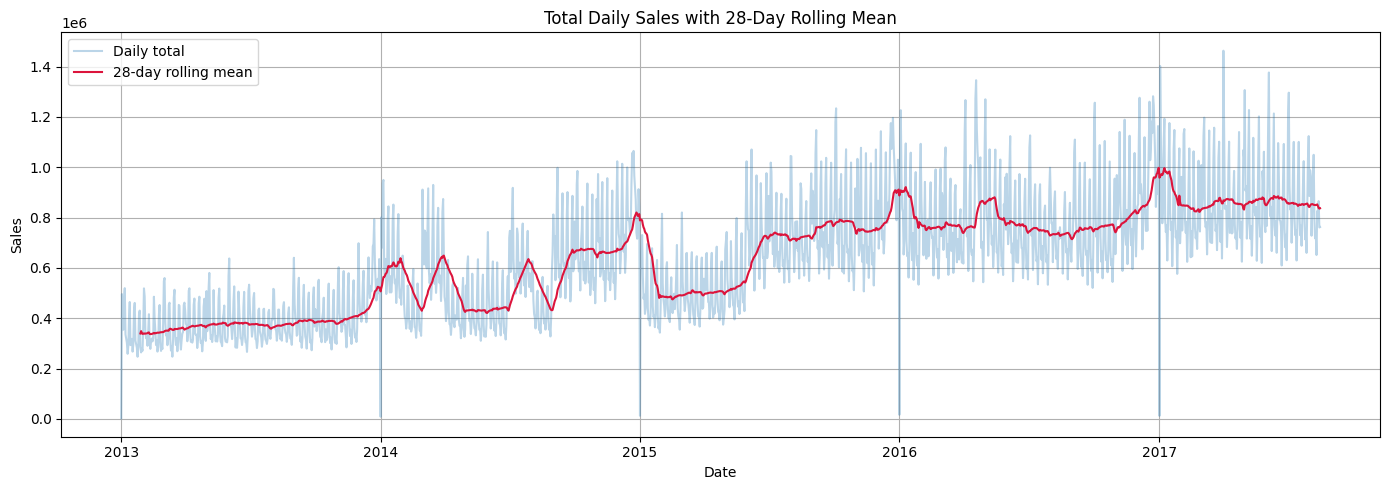

In [29]:
# Daily sales with 28 day rolling mean
daily_total_df = daily_total.reset_index()
daily_total_df["roll_28"] = daily_total_df["sales"].rolling(28).mean()

fig, ax = plt.subplots()
ax.plot(daily_total_df["date"], daily_total_df["sales"], alpha=0.3, label="Daily total")
ax.plot(daily_total_df["date"], daily_total_df["roll_28"], color="crimson", label="28-day rolling mean")
ax.set_title("Total Daily Sales with 28-Day Rolling Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.tight_layout()
plt.show()

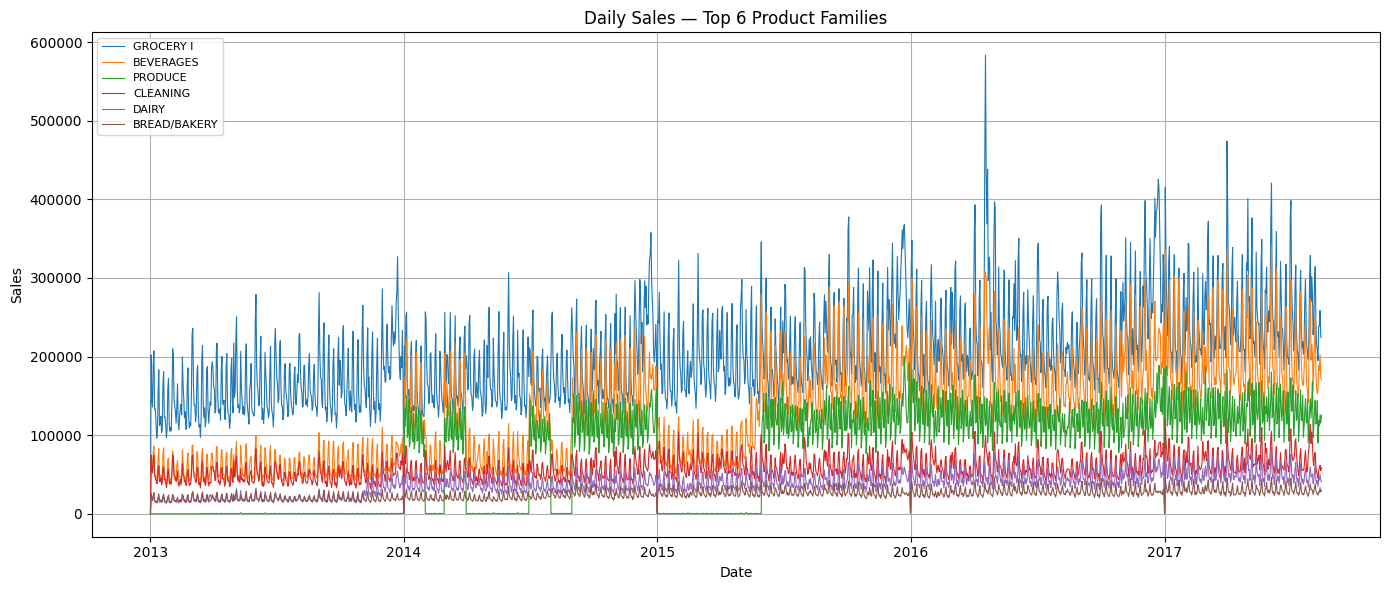

In [30]:
# Top 6 product families over time
top_families = train.groupby("family")["sales"].sum().sort_values(ascending=False).head(6).index

fig, ax = plt.subplots(figsize=(14, 6))
for fam in top_families:
    fam_daily = train[train["family"] == fam].groupby("date")["sales"].sum()
    ax.plot(fam_daily.index, fam_daily.values, label=fam, linewidth=0.8)

ax.set_title("Daily Sales — Top 6 Product Families")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

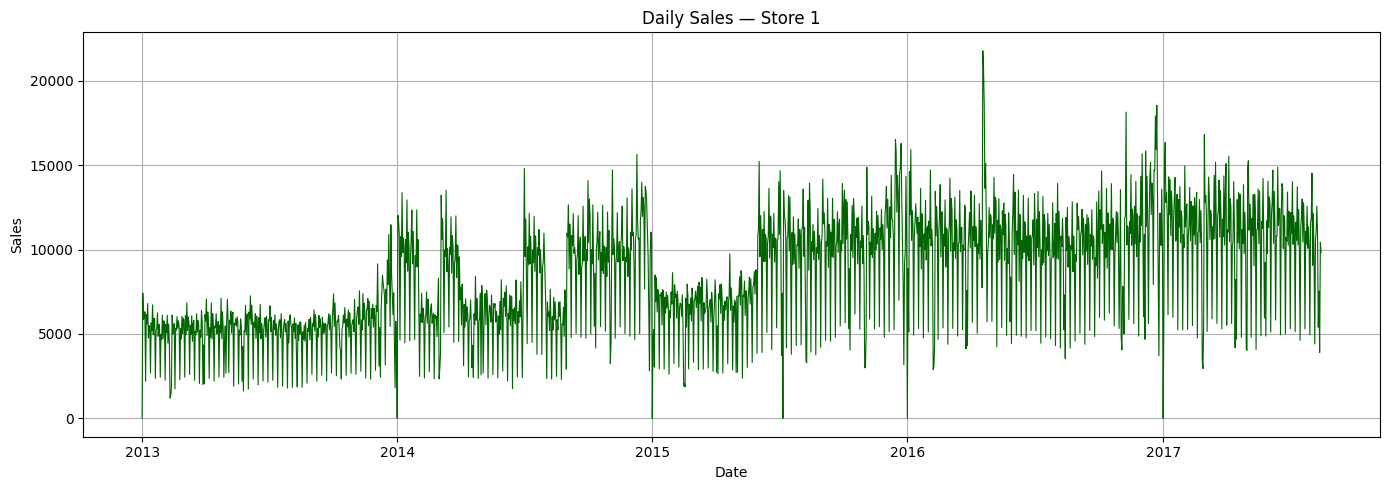

In [31]:
# Single store's sales
store_id = 1  # <-- change to inspect a different store

store_daily = train[train["store_nbr"] == store_id].groupby("date")["sales"].sum()

fig, ax = plt.subplots()
ax.plot(store_daily.index, store_daily.values, linewidth=0.8, color="darkgreen")
ax.set_title(f"Daily Sales — Store {store_id}")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

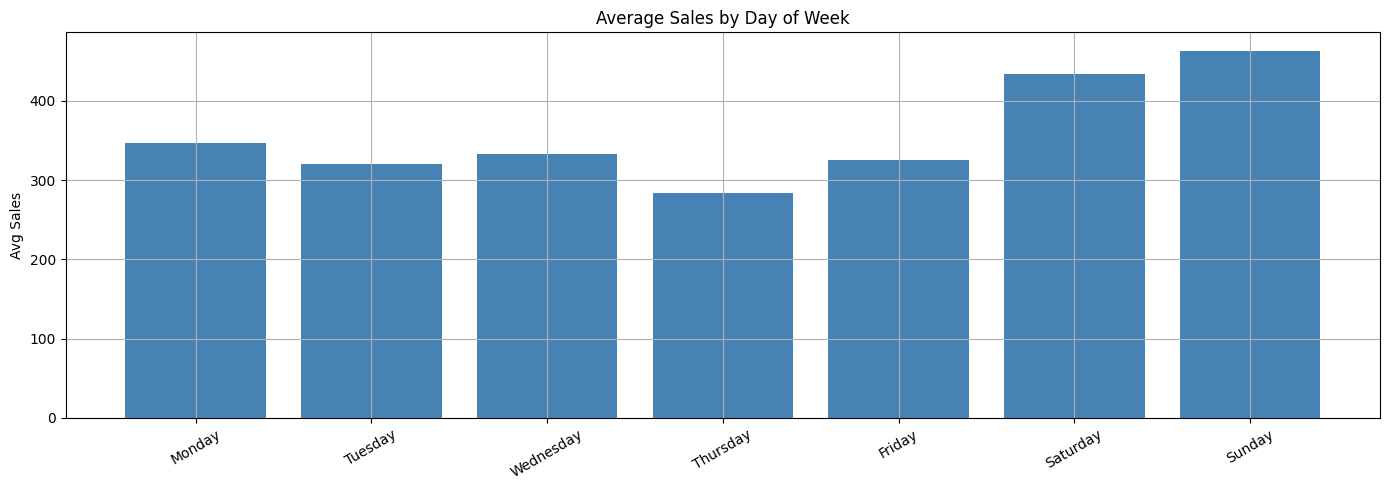

In [32]:
# Average sales by day of week
dow_avg = train.copy()
dow_avg["dayofweek"] = dow_avg["date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_avg = dow_avg.groupby("dayofweek")["sales"].mean().reindex(order)

fig, ax = plt.subplots()
ax.bar(dow_avg.index, dow_avg.values, color="steelblue")
ax.set_title("Average Sales by Day of Week")
ax.set_ylabel("Avg Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

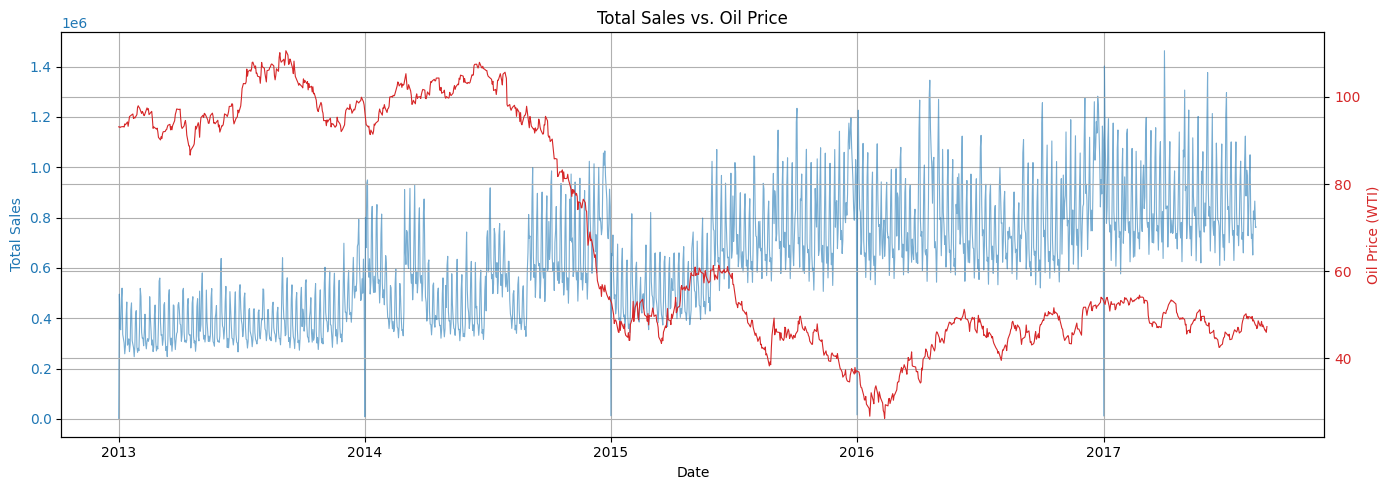

In [33]:
# oil prive vs total sales 
fig, ax1 = plt.subplots()

ax1.plot(daily_total.index, daily_total.values, color="tab:blue", alpha=0.6, linewidth=0.8)
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Sales", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(oil["date"], oil["oil_price"], color="tab:red", linewidth=0.8)
ax2.set_ylabel("Oil Price (WTI)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Total Sales vs. Oil Price")
plt.tight_layout()
plt.show()